In [1]:
import pandas as pd
df = pd.read_csv('sentiment_analysis_results.csv')

In [2]:
df

,Text,CleanedReview,Score,Sentiment,PredictedSentiment
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,5,Positive,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,1,Negative,Negative
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...,4,Positive,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...,2,Negative,Positive
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,5,Positive,Positive
...,...,...,...,...,...
568449,Great for sesame chicken..this is a good if no...,great sesame chickenthis good better resturant...,5,Positive,Positive
568450,I'm disappointed with the flavor. The chocolat...,im disappointed flavor chocolate note especial...,2,Negative,Negative
568451,"These stars are small, so you can give 10-15 o...",star small give one training session tried tra...,5,Positive,Positive
568452,These are the BEST treats for training and rew...,best treat training rewarding dog good groomin...,5,Positive,Positive


# 1. Sentiment Distribution

/var/folders/3l/67y0958d03l9598gqq_b3f6m0000gn/T/ipykernel_11472/3188635173.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PredictedSentiment', data=df, palette='coolwarm')


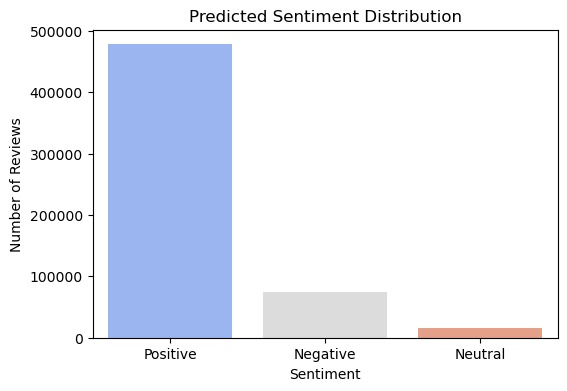

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='PredictedSentiment', data=df, palette='coolwarm')
plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


In [ ]:
# 2. Sentiment vs. Score

# 2. Sentiment vs. Score

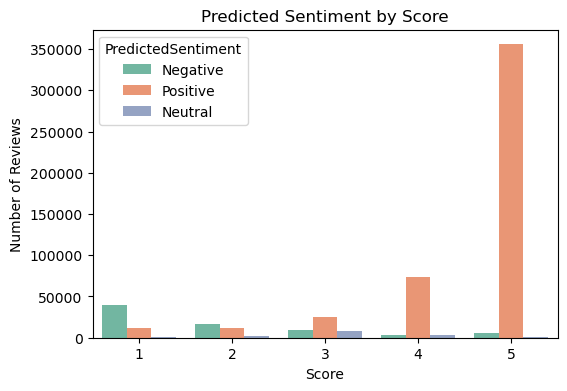

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Score', hue='PredictedSentiment', data=df, palette='Set2')
plt.title('Predicted Sentiment by Score')
plt.xlabel('Score')
plt.ylabel('Number of Reviews')
plt.show()


# 3. Wordclouds for Positive & Negative Reviews

In [6]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [8]:
import wordcloud
print("WordCloud installed successfully!")


WordCloud installed successfully!


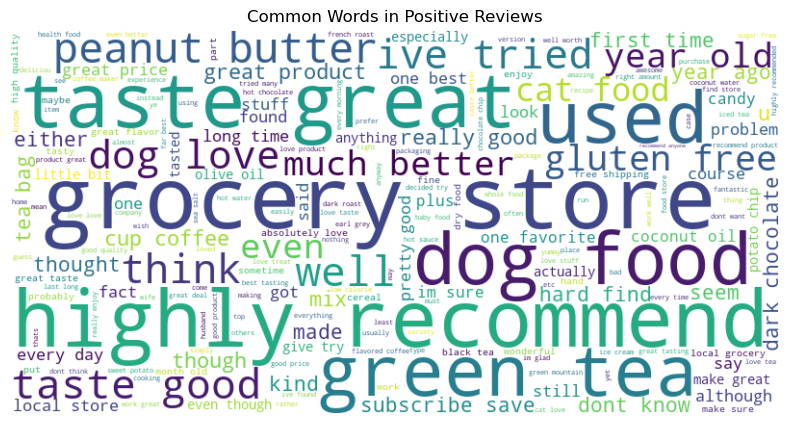

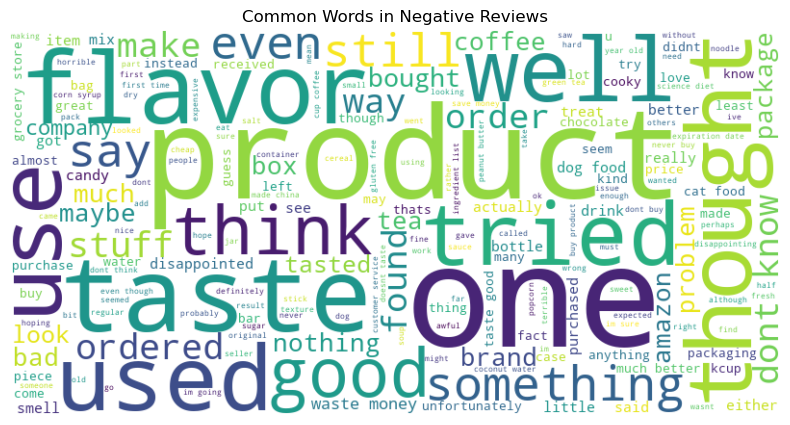

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert to string and drop NaN
positive_text = ' '.join(df[df['PredictedSentiment'] == 'Positive']['CleanedReview'].dropna().astype(str))
negative_text = ' '.join(df[df['PredictedSentiment'] == 'Negative']['CleanedReview'].dropna().astype(str))

# Generate WordClouds
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

# Display Positive WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Positive Reviews')
plt.show()

# Display Negative WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Negative Reviews')
plt.show()


# 4. Top Keywords

In [12]:
from collections import Counter

# Positive reviews
positive_text = ' '.join(df[df['PredictedSentiment']=='Positive']['CleanedReview'].dropna().astype(str))
positive_words = positive_text.split()
top_positive = Counter(positive_words).most_common(10)
print("Top Positive Words:", top_positive)

# Negative reviews
negative_text = ' '.join(df[df['PredictedSentiment']=='Negative']['CleanedReview'].dropna().astype(str))
negative_words = negative_text.split()
top_negative = Counter(negative_words).most_common(10)
print("Top Negative Words:", top_negative)


Top Positive Words: [('like', 211148), ('good', 171377), ('taste', 164302), ('great', 153903), ('one', 153656), ('love', 152807), ('flavor', 150315), ('coffee', 141121), ('product', 132366), ('tea', 131205)]
Top Negative Words: [('like', 40988), ('product', 38009), ('taste', 36640), ('one', 27321), ('would', 25743), ('food', 21822), ('flavor', 21254), ('coffee', 20781), ('good', 17409), ('dont', 16111)]
